In [15]:
import pandas as pd
df = pd.read_csv('flight_pricing_dataset.csv')
df.head()

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,Economy,43,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,non-stop,150,Economy,45,Monsoon,Thursday,ATR 72,Website,3,2000
2,FL173851,Qatar Airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.80,1 stop,10168.1,Economy,3,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69
3,FL101953,AirAsia India,Bangalore Airport,BOM,2025-04-19,07:05,10:16 AM,3h 11m,1,868.3,Economy,33,Summer,Saturday,Airbus A320,Mobile App,1,2846.09
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,non-stop,10478.0,Economy,6,Monsoon,Sunday,Airbus A320,Website,2,145331.64


In [16]:
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna()
print("Price column successfully converted to numbers!")

Price column successfully converted to numbers!


In [17]:
print("--- Dataset Info ---")
df.info()
print("\n--- Missing Values ---")
df.isnull().sum()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 41457 entries, 0 to 99998
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Flight_ID              41457 non-null  object 
 1   Airline                41457 non-null  object 
 2   Source                 41457 non-null  object 
 3   Destination            41457 non-null  object 
 4   Departure_Date         41457 non-null  object 
 5   Departure_Time         41457 non-null  object 
 6   Arrival_Time           41457 non-null  object 
 7   Duration               41457 non-null  object 
 8   Total_Stops            41457 non-null  object 
 9   Distance_km            41457 non-null  object 
 10  Travel_Class           41457 non-null  object 
 11  Days_Before_Departure  41457 non-null  object 
 12  Season                 41457 non-null  object 
 13  Weekday                41457 non-null  object 
 14  Aircraft_Type          41457 non-null 

,0
Flight_ID,0
Airline,0
Source,0
Destination,0
Departure_Date,0
Departure_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Distance_km,0


In [18]:
df = df.dropna()
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())
print(f"\nTotal rows and columns remaining: {df.shape}")

--- Missing Values After Cleaning ---
Flight_ID                0
Airline                  0
Source                   0
Destination              0
Departure_Date           0
Departure_Time           0
Arrival_Time             0
Duration                 0
Total_Stops              0
Distance_km              0
Travel_Class             0
Days_Before_Departure    0
Season                   0
Weekday                  0
Aircraft_Type            0
Booking_Channel          0
Passenger_Count          0
Price                    0
dtype: int64

Total rows and columns remaining: (41457, 18)


In [19]:
print(df.columns.tolist())

['Flight_ID', 'Airline', 'Source', 'Destination', 'Departure_Date', 'Departure_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Distance_km', 'Travel_Class', 'Days_Before_Departure', 'Season', 'Weekday', 'Aircraft_Type', 'Booking_Channel', 'Passenger_Count', 'Price']


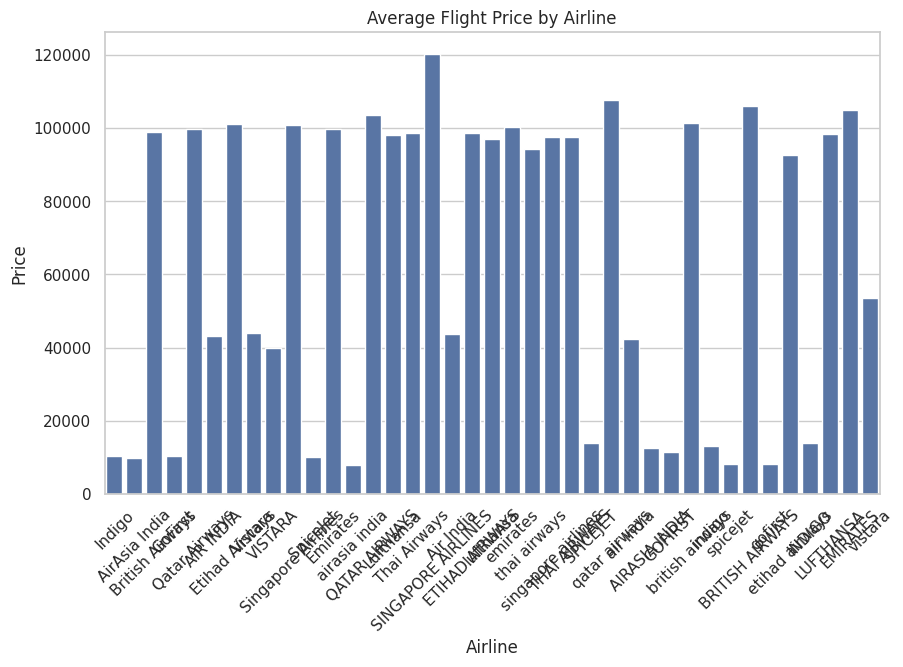

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Airline', y='Price', errorbar=None)
plt.title('Average Flight Price by Airline')
plt.xticks(rotation=45)
plt.show()

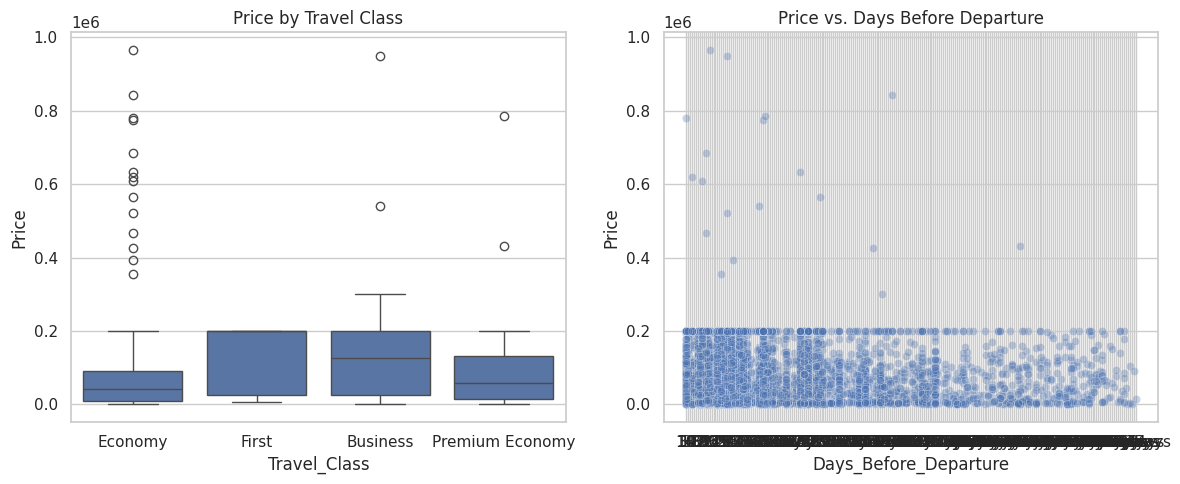

In [21]:
df_sample = df.sample(5000, random_state=42)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_sample, x='Travel_Class', y='Price')
plt.title('Price by Travel Class')
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_sample, x='Days_Before_Departure', y='Price', alpha=0.3)
plt.title('Price vs. Days Before Departure')
plt.tight_layout()
plt.show()

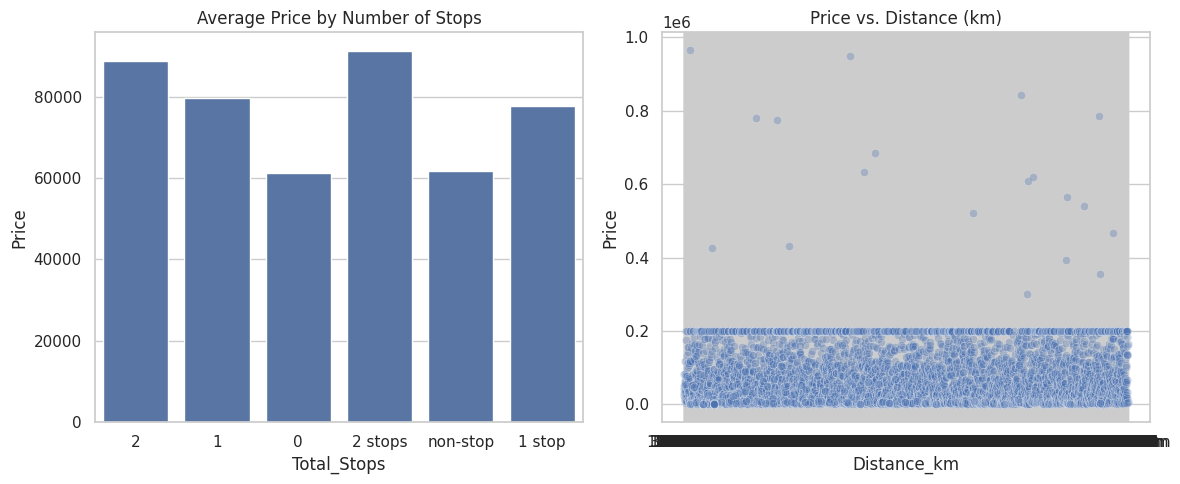

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=df_sample, x='Total_Stops', y='Price', errorbar=None)
plt.title('Average Price by Number of Stops')
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_sample, x='Distance_km', y='Price', alpha=0.3)
plt.title('Price vs. Distance (km)')
plt.tight_layout()
plt.show()